# Dataset Cartography com Training Dynamics

Foi implementado um **Data Map** sobre o dataset Wine seguindo a metodologia apresentada em **Swayamdipta et al. (2020), *Dataset Cartography: Mapping and Diagnosing Datasets with Training Dynamics***.

Os dados foram divididos de forma estratificada em:

* **60% — treino**;
* **20% — validação**;
* **20% — teste**.

As features foram padronizadas com **StandardScaler** e uma MLP em PyTorch, com uma camada oculta de **32 neurônios e ReLU**, foi treinada durante **50 épocas** utilizando `CrossEntropyLoss` e `Adam`.

Ao final de cada época são registradas, individualmente para cada amostra de treinamento:

* a probabilidade atribuída à **classe correta**;
* a corretude da classificação naquela época.

A partir dessas **training dynamics**, são calculadas três métricas por exemplo:

* **Confiança:** média da probabilidade atribuída à classe correta;
* **Variabilidade:** desvio padrão dessa probabilidade ao longo das épocas;
* **Corretude:** fração de épocas em que a instância foi classificada corretamente.

Essas métricas são utilizadas para construir os **Data Maps**, permitindo investigar exemplos *easy-to-learn*, *ambiguous* e *hard-to-learn*, além de analisar possíveis amostras difíceis ou inconsistentes no conjunto de treinamento.

**Referência:** Swayamdipta, S. et al. (2020). *Dataset Cartography: Mapping and Diagnosing Datasets with Training Dynamics*. EMNLP 2020.


#### Pré Processamento, definição e treino 



In [ ]:
# 1. Importação 
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 2. Carregamento e divisão 
X, y = load_wine(return_X_y=True)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


# 3. Normalização para igualar as escalas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # .fit_transform ajusta o scaler com dados de treino e transforma todos os outros dados
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Exibição das dimensões e primeiras linhas
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("Primeiras linhas de X_train:\n", X_train[:5])
print("Primeiros valores de y_train:", y_train[:10])

X_train shape: (106, 13)
X_val shape: (36, 13)
X_test shape: (36, 13)
Primeiras linhas de X_train:
 [[ 0.95817987 -0.68509096  1.2406911   0.00903313  2.06926091  1.08120553
   0.78503623  1.20204481 -0.44822156  0.12419372  1.24696915  0.63687539
   1.52698895]
 [-0.35275089 -1.21898754 -0.41265949 -0.48623138 -0.1109423  -0.12790742
  -0.05317924 -0.49797854 -0.25906979 -1.01378527  1.16178598  0.87484425
  -0.97042148]
 [ 0.74169589 -0.55889723  0.01864936 -0.12303741  0.35152505  0.93611197
   1.25653243 -1.17798787  0.58351536  0.73821116  0.56550377  0.45839874
   2.41778503]
 [ 1.07844875 -0.70450539  1.13286389  1.82500297 -0.96981023  1.08120553
   0.91076855 -1.26298904  0.44595044 -0.7026831   1.71547661  0.87484425
  -1.09767806]
 [ 0.10427085 -0.18031601  3.10969612  1.82500297  1.5407268   0.56531734
   0.72217007  0.94704131  0.53192851 -0.62081411  0.73587011  0.93433647
   0.23851605]]
Primeiros valores de y_train: [0 1 0 1 0 0 2 0 1 0]


In [ ]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [ ]:
import torch.nn as nn

class MLP(nn.Module): # Definição de uma rede neural simples (MLP) com uma camada oculta
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(X.shape[1], 32) # X.shape[1] é o número de features e 32 é o número de neurônios na camada oculta 
        self.relu = nn.ReLU() # Função de ativação ReLU para introduzir não-linearidade
        self.output = nn.Linear(32, 3)  # 3 classes no wine

    def forward(self, x): # Método de propagação direta
        x = self.relu(self.hidden(x)) # Aplica a camada oculta seguida da função de ativação ReLU
        return self.output(x) # Retorna a saída bruta da camada final, que produz logits para as 3 classes

model = MLP()


In [ ]:
# Adam usa Momentum (velocidade de mudança dos pesos) e RMSprop (ajuste do passo com base no histórico do gradiente).
import torch.optim as optim # Otimizador Adam para atualizar os pesos da rede neural
import torch.nn as nn # Biblioteca para construir redes neurais em PyTorch


loss_fn = nn.CrossEntropyLoss() # Função de perda de entropia cruzada para classificação multiclasse
optimizer = optim.Adam(model.parameters(), lr=0.01) # Otimizador Adam para atualizar os pesos da rede neural lr = taxa de aprendizado
losses = [] # Lista para armazenar as perdas durante o treinamento

probs = [] # Lista para armazenar as probabilidades previstas durante o treinamento
correct = [] # Lista para armazenar as previsões corretas durante o treinamento

for epoch in range(50): # Treinamento por 50 
    model.train() # Muda o modelo para o modo de treinamento
    outputs = model(X_train_t) # Propagação direta: calcula as previsões da rede neural para os dados de treino
    loss = loss_fn(outputs, y_train_t) # Calcula a perda entre as previsões e os rótulos reais
    losses.append(loss.item()) # Armazena a perda para análise posterior

    # Backpropagation: calcula os gradientes da perda em relação aos pesos da rede neural
    optimizer.zero_grad() # Zera os gradientes acumulados do otimizador
    loss.backward() # Calcula os gradientes da perda em relação aos pesos da rede neural
    optimizer.step() # Atualiza os pesos da rede neural com base nos gradientes calculados

    with torch.no_grad(): # Desativa o cálculo de gradientes para economizar memória e acelerar a computação
        pred_probs = torch.softmax(outputs, dim=1).cpu().numpy() # Calcula as probabilidades previstas usando a função softmax
        epoch_probs = pred_probs[np.arange(len(y_train)), y_train] # Extrai as probabilidades correspondentes às classes reais
        probs.append(epoch_probs) # Armazena as probabilidades previstas para análise posterior

        preds = np.argmax(pred_probs, axis=1) # Obtém as classes previstas pela rede neural, escolhendo a classe com a maior probabilidade
        epoch_correct = (preds == y_train).astype(int) # Compara as classes previstas com as classes reais e converte o resultado em 0s e 1s (0 para incorreto, 1 para correto)
        correct.append(epoch_correct) # Armazena as previsões corretas para análise posterior


#### Calcular confiança, variabilidade e corretude

In [ ]:
probs = np.stack(probs, axis=1) # Empilha as probabilidades previstas ao longo das épocas
correct = np.stack(correct, axis=1) # Empilha as previsões corretas ao longo das épocas
confidence = probs.mean(axis=1) # Calcula a confiança média das previsões ao longo das épocas
variability = probs.std(axis=1) # Calcula a variabilidade das previsões ao longo das épocas
accuracy_ratio = correct.mean(axis=1) # Calcula a proporção de previsões corretas ao longo das épocas

#### Criando DataFrame

In [ ]:
df_map = pd.DataFrame({
    'confiança': confidence,
    'variabilidade': variability,
    'corretude': accuracy_ratio,
    'classe': y_train
})

#### Plotar Data Map por corretude

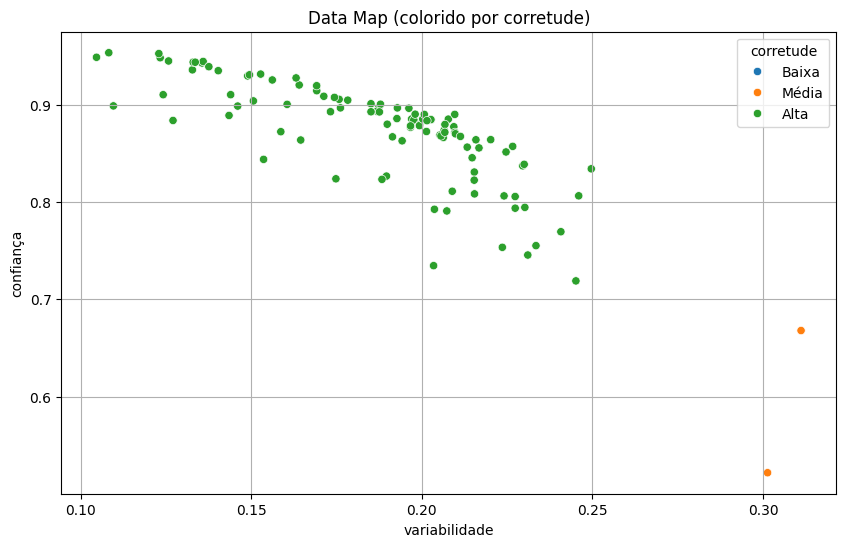

In [ ]:
plt.figure(figsize=(10, 6))
# Plotar Data Map colorido por corretude
sns.scatterplot(data=df_map, x='variabilidade', y='confiança', hue=pd.cut(df_map['corretude'], bins=[0, 0.3, 0.7, 1], labels=['Baixa', 'Média', 'Alta']))
plt.title("Data Map (colorido por corretude)")
plt.grid(True)
plt.show()

####  Plotar DataMap por classe

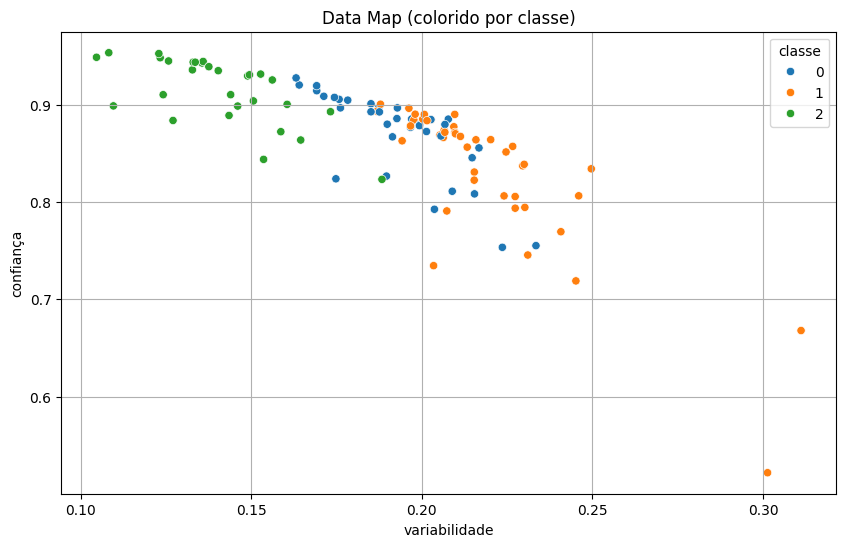

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_map, x='variabilidade', y='confiança', hue='classe', palette='tab10')
plt.title("Data Map (colorido por classe)")
plt.grid(True)
plt.show()

####  Procurando inconsistências

In [ ]:
# Exemplo com thresholds ajustados
suspeitos = df_map[
    (df_map['confiança'] < 0.6) &
    (df_map['variabilidade'] > 0.27)
]
print(suspeitos)



     confiança  variabilidade  corretude  classe
100   0.521628        0.30134        0.5       1
